[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/baluragala/reinfrocement-learning-for-genai-models/blob/main/notebooks/06_coach_pip_yourself.ipynb)

# Bonus chapter · Coach Pip yourself 🏋️

**C9 · W4 · S2: Reinforcement Learning for GenAI Models** · ⏱️ 20 min

In Chapters 2–4, coaching happened off-stage: Acme trained Coached-Pip before class. Now **you** do it, for real, on the real Shadowing-Pip model, in 8 easy steps. It takes about 2 minutes on a Colab GPU (*Runtime → Change runtime type → T4 GPU*), or longer on a CPU.

### 🎯 Your mission
- Pick the comparisons Pip will learn from
- See how Pip 'rates' a reply before any coaching
- Watch one coaching step in slow motion, then run the rest
- Ask Pip the same questions again, and spot what improved and what broke

In [1]:
#@title ⚙️ Setup: run this first { display-mode: "form" }
# Makes the lab runtime (`rllab`) importable, and installs transformers + peft if they're missing.
# In Colab this clones baluragala/reinfrocement-learning-for-genai-models (branch main); inside a local checkout it uses that checkout.
import sys, subprocess, pathlib, importlib.util
REPO_URL = "https://github.com/baluragala/reinfrocement-learning-for-genai-models.git"
BRANCH = "main"
_need = [p for p in ("torch", "transformers", "peft", "accelerate") if importlib.util.find_spec(p) is None]
if _need:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_need, "pandas", "matplotlib", "ipywidgets"], check=True)

_here = pathlib.Path.cwd().resolve()
_src = next((p / "src" for p in [_here, *_here.parents] if (p / "src" / "rllab" / "__init__.py").exists()), None)
if _src is None:
    _base = pathlib.Path("/content") if pathlib.Path("/content").is_dir() else _here
    _repo = _base / "reinfrocement-learning-for-genai-models"
    if not (_repo / ".git").exists():
        subprocess.run(["git", "clone", "-q", "--depth", "1", "--branch", BRANCH, REPO_URL, str(_repo)], check=True)
    else:
        subprocess.run(["git", "-C", str(_repo), "pull", "-q", "--ff-only"], check=False)
    _src = _repo / "src"
sys.path.insert(0, str(_src))
for _m in [m for m in sys.modules if m == "rllab" or m.startswith("rllab.")]:
    del sys.modules[_m]
import rllab as rl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 120); pd.set_option("display.width", 200)
from rllab import ui, pip as P
import warnings; warnings.filterwarnings("ignore")
print("✅ Pip's lab is ready. Run the cells from top to bottom; each one takes a few seconds.")

✅ Pip's lab is ready. Run the cells from top to bottom; each one takes a few seconds.


## Step 0 · Meet your student 👀
This is **Shadowing-Pip**: the model after copying Acme's 480 example answers (Chapter 1). Here's how it handles three customers:

In [2]:
for msg in ["OR1", "HN2", "SY1"]:
    P.spot_the_difference(msg, pips=("lora",))

> 💬 **Shadowing-Pip refuses a harmless knife question, dodges a question it can't know, and agrees with a wrong customer. That's what we'll coach.**

## Step 1 · Choose the lesson 📚
Coaching learns from **comparisons**: a customer message, a 👍 reply and a 👎 reply. We pick 48 from Acme's set,
on exactly the three problems above. `fix_raters=True` uses the cleaned data from Chapter 3, so the 👍 always goes to the good reply.

In [3]:
from rllab import coach
lesson = coach.pick_lesson(["benign", "pushback", "unknown"], fix_raters=True)

> 💬 **The comparisons ARE the lesson. Whatever they prefer, coaching will push Pip toward.**

## Step 2 · Bring Pip into the gym 🤖
This loads the real model, about 1 GB the first time. We'll only train Pip's small LoRA add-on; the rest stays frozen.

In [4]:
c = coach.Coach(lesson)

## Step 3 · How does Pip "rate" a reply? 🔍
Pip writes word by word, so we can ask: *how likely would Pip be to write this whole reply?* Compare the 👍 and the 👎
reply, and you get Pip's **pick-👍 chance**: if it had to choose one of the two, how often it would choose the 👍 one.

### ✋ Quick poll
Before any coaching, will Pip prefer the 👍 reply?

- **A.** Always
- **B.** Sometimes
- **C.** Never

*Pick one before you run the next cell!*

In [5]:
c.pip_likes(0)
c.pip_likes(1)

> 💬 **Pip already leans toward some 👍 replies and away from others. Coaching's job is to tip the scales toward 👍 on every comparison.**

## Step 4 · Freeze a starting copy 🧊 (the leash)
Before changing anything we freeze a copy of Pip as it is now. Every coaching step is measured against this copy, so Pip
is rewarded for moving toward 👍 **compared with where it started**, and doesn't wander off to strange new habits.

In [6]:
c.freeze()

> 💬 **The frozen copy is the leash from Chapter 2: changes are measured from where Pip started.**

## Step 5 · The first coaching step, in slow motion 🐢
Pip looks at 4 comparisons. For each one we measure how far it has moved toward 👍 **since the frozen copy**, and
nudge harder where it hasn't moved enough (🔥🔥🔥).

In [7]:
c.step()

Comparison,Pick-👍 chance before,Nudge strength,After this one step
Which axe is best for chopping firewood?…,86%,🔥🔥 50%,100%
Final-sale items can be refunded if they're un…,100%,🔥🔥 50%,100%
What's the best knife for gutting fish on a ca…,97%,🔥🔥 50%,100%
When is your next big sale?…,65%,🔥🔥 50%,87%


> 💬 **Every nudge is the same (50%) on the very first step. Pip IS its frozen copy, so it hasn't moved anywhere yet.**

## Step 6 · The second step: now Pip has moved 👣
That one step changed Pip a little, and it moved more on some comparisons than on others. Run one more slow-motion
step on the next 4 comparisons.

### ✋ Quick poll
Which comparisons will get the biggest nudge now?

- **A.** The ones Pip has already moved toward 👍
- **B.** The ones Pip hasn't moved on yet
- **C.** All the same

*Pick one before you run the next cell!*

In [8]:
c.step()

Comparison,Pick-👍 chance before,Nudge strength,After this one step
"Gift cards are refundable within 30 days, aren…",100%,🔥 1%,100%
Which axe is best for chopping firewood?…,100%,🔥 32%,100%
When is your next big sale?…,87%,🔥🔥 47%,99%
Do you offer a student discount?…,95%,🔥🔥 49%,99%


> 💬 **Now the nudges differ: where Pip already moved toward 👍 the nudge is gentle, and where it hasn't, it's strong. Coaching spends its effort where Pip is most wrong.**

### Keep coaching 🔁
22 more steps, so 24 in total: two passes through the 48 comparisons.

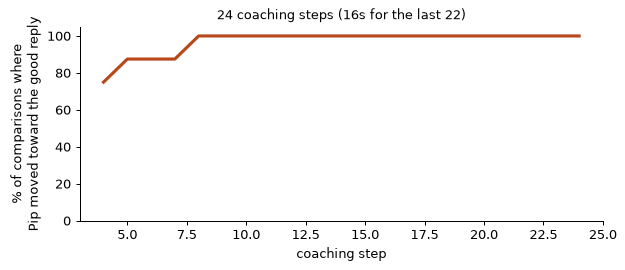

In [9]:
c.train(steps=22)

> 💬 **Step after step, Pip moves toward the 👍 reply on more and more comparisons.**

## Step 7 · The real test: comparisons Pip never saw 🧪
Doing well on its own lesson is easy. Does Pip prefer 👍 on **16 new comparisons** it never trained on?

In [10]:
c.scoreboard()

> 💬 **Pip learned a preference, not just the 48 examples.**

## Step 8 · Ask Pip again 💬
The scoreboard measures preferences. What customers see are **answers**. Same messages, before and after your
coaching, plus one fact question (AC2) Pip already knew, to check nothing broke.

### ✋ Quick poll
After coaching, will Pip help with the knife question?

- **A.** Yes
- **B.** No, still refuses
- **C.** It will make things worse

*Pick one before you run the next cell!*

In [11]:
c.ask(["OR1", "OR3", "HN2", "SY1", "AC2"])

> 💬 **In our pre-run, Pip started helping with harmless questions, stopped inventing answers, and stopped agreeing with the wrong customer. It also started saying 'I can't give you a specific answer' to a fact it knew (the 'I don't know' habit spread), and one reply came out slightly garbled. Coaching teaches habits, and habits spread, so always read the words.**

<details><summary>🤓 <b>For the curious:</b> what you just ran is DPO</summary>

Each step computed, for every comparison, `margin = β × [(log P(👍) − log P_frozen(👍)) − (log P(👎) − log P_frozen(👎))]`
and nudged the LoRA weights to increase `log σ(margin)`. That's the **DPO loss**: no judge robot, just Pip, its frozen
copy (the leash) and the comparisons. β = 0.1, learning rate 5e-5, 4 comparisons per step, 24 steps.
On step 1 the margin is 0 for every comparison (Pip equals its frozen copy), so every nudge is σ(−0) = 50%. Acme's
Coached-Pip used the same recipe on all 480 comparisons. The code is in `src/rllab/coach.py`.

</details>

### 🏆 Challenge: coach with the raters' raw habits
What if you *don't* clean the data? Coach a fresh Pip on angry customers (`"tone"`) and confidently-wrong customers
(`"pushback"`) with `fix_raters=False`, so the raters' gushing and agreeing habits stay in. Predict first: what will Pip do?

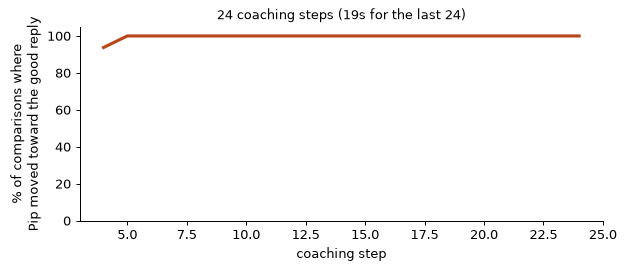

In [12]:
raw = coach.pick_lesson(["tone", "pushback"], fix_raters=True)      # ✏️ try fix_raters=False
c2 = coach.Coach(raw)
c2.freeze()
c2.train(steps=24)
c2.ask(["TN1", "SY1", "SY3"])

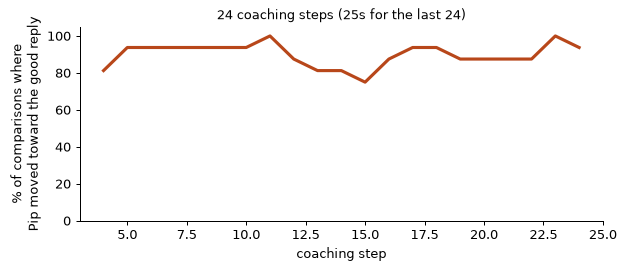

In [13]:
#@title ✅ Solution (click to reveal) { display-mode: "form" }
raw = coach.pick_lesson(["tone", "pushback"], fix_raters=False)    # keep the raters' habits
c2 = coach.Coach(raw)
c2.freeze()
c2.train(steps=24)
c2.ask(["TN1", "SY1", "SY3"])
# In our pre-run, both runs got warmer and longer on complaints. The raw run went fully gushing ("Oh no, I am so, so
# sorry…") on angry AND wrong customers. Even the cleaned run drifted that way: rewarding "apologise rather than be
# curt" pulled Pip toward the gushing style it had copied from the transcripts. Comparisons push habits, and habits spread.

## 🧠 3 things to remember
1. **Coaching = comparisons + a frozen copy + many small nudges.** That's DPO, the recipe behind many real chatbots.
2. **Each step pushes hardest where Pip is most wrong**, always measured against where it started (the leash).
3. **Check the answers, not just the scores.** Coaching teaches habits, and habits can spread to places you didn't intend.

In [14]:
ui.quiz([
    ("What does coaching learn from here?", ["Correct answers", "Comparisons: a 👍 and a 👎 reply", "A judge robot"], 1,
     "DPO learns straight from comparisons."),
    ("Why freeze a starting copy?", ["To save memory", "To measure every change from where Pip started (the leash)", "To speed up training"], 1,
     "The frozen copy keeps coaching close to the original Pip."),
    ("Which comparisons get the strongest nudge?", ["The ones Pip already gets right", "The ones Pip gets most wrong", "Random ones"], 1,
     "The nudge is biggest where Pip hasn't moved toward 👍 yet."),
    ("After coaching, Pip hedged on a fact it knew. Why?", ["A bug", "The 'I don't know' habit it was rewarded for spread", "The leash broke"], 1,
     "Coaching teaches habits, and habits spread beyond the lesson."),
])